# Python & Colab Quick-Start— for the Probablilistic Modeling Notebook

This notebook teaches you *just enough* Python and Google Colab to understand and run a "prediciton model" on your own. It's short on purpose — every section here exists because the weather-model code actually uses it. By the end, we'll walk through that exact code together, piece by piece.

**How to work through this:** click a code cell (gray box) and press **Shift + Enter** to run it, then move to the next one. Run everything top to bottom, in order — later cells assume earlier ones already ran. If anything gets confusing, use **Runtime → Restart runtime** and start over from the top.

## 0. What is a Colab notebook?

A notebook is a document made of **cells**. Some cells are text (like this one — written in Markdown, just for reading). Some cells are **code** — real Python that actually runs when you press Shift+Enter.

A few things that trip people up the first time:
- Cells share variables with each other, in the order you *run* them (not necessarily the order they appear on the page). If you skip a cell, anything it would have created doesn't exist yet.
- **Runtime** = the Python engine running in the background. If things start behaving strangely, `Runtime → Restart runtime` gives you a clean slate.
- Nothing you do here can break your computer — it's all running on Google's servers, not your machine.

Try running this:

In [ ]:
print("You just ran a code cell.")

You just ran a code cell.


## 1. Python syntax at a glance

Before diving into specific tools, here's the general shape of Python code — the patterns you'll see in every cell from here on.

- **Comments**: anything after a `#` is ignored by Python — it's just a note for humans reading the code.
- **No semicolons needed**: each line is one instruction; you don't end it with `;` the way some other languages require.
- **Assignment (`=`) vs. comparison (`==`)**: `x = 5` *stores* the value 5 in `x`. `x == 5` *asks* whether `x` equals 5, and gives back `True` or `False`. Mixing these two up is one of the most common early bugs.
- **Function calls**: `something(argument1, argument2)` — a name followed by parentheses holding whatever it needs, like `print("hello")` or `range(50)`.
- **Dot notation**: `np.array(...)` reads as “the `array` tool, which lives inside `np`.” You'll see this `library.tool(...)` pattern constantly.
- **Colons and indentation**: any line ending in `:` — you'll see this with `for`, `if`, and `def` — is followed by an indented block that belongs to it. Python uses indentation (usually 4 spaces) instead of curly braces `{}` or an `end` keyword to mark what's inside a block. Get the indentation wrong and Python will either error out or (worse) silently do something you didn't intend.


In [ ]:
x = 5          # assignment: store 5 in x
print(x == 5)  # comparison: asks a yes/no question, prints True

for i in range(3):      # this line ends in a colon
    print(i)            # indented -> part of the loop
print("done")            # not indented -> runs after the loop, only once

True
0
1
2
done


Every piece of code in this notebook — and in `L01_weather.ipynb` itself — follows exactly these rules. Once you can read this pattern, you can read any Python.

## 2. Importing libraries

Python itself is small — almost everything useful comes from **libraries** you import at the top of your notebook. The weather-model code starts with exactly two:

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

- `numpy` (imported with the nickname `np`) is *the* library for arrays and matrix math in Python — you'll use it constantly this term.
- `matplotlib.pyplot` (nicknamed `plt`) is for making plots.

Nothing prints here — importing just makes the tools available for later cells.

## 3. NumPy arrays — vectors and matrices

A **list** in plain Python (`[1, 2, 3]`) can hold numbers, but it can't do matrix math. For that we use a **NumPy array**.

In [ ]:
# A 1D array — think of this as a vector
x = np.array([1, 0, 0])
print(x)
print(type(x))

[1 0 0]
<class 'numpy.ndarray'>


In [ ]:
# A 2D array — a matrix. Each inner [ ] is one row.
A = np.array([[0.5, 0.5, 0.25],
              [0.25, 0, 0.25],
              [0.25, 0.5, 0.5]])
print(A)
print("shape:", A.shape)   # (rows, columns)

[[0.5  0.5  0.25]
 [0.25 0.   0.25]
 [0.25 0.5  0.5 ]]
shape: (3, 3)


This particular matrix `A` is exactly the one used in the prediction model — each column describes how likely what food the cafe will serve, given today's. We'll come back to what it means in a minute.

## 4. Matrix-vector multiplication with `@`

In NumPy, the `@` symbol means **matrix multiplication** (this is different from `*`, which multiplies element-by-element — a common early mixup, so it's worth trying both to see the difference).

In [ ]:
result = A @ x
print(result)

[0.5  0.25 0.25]


In [ ]:
# Compare: * multiplies element-by-element instead (only works here because
# A's shape happens to allow it — this is NOT matrix multiplication)
print(A * x)

[[0.5  0.   0.  ]
 [0.25 0.   0.  ]
 [0.25 0.   0.  ]]


**Why this matters for the prediction model:** if `x` represents today's state (as probabilities of pork/chichen/fish, say), then `A @ x` gives you *tomorrow's* state. This is the entire mathematical idea behind the notebook — a vector describing "now" gets turned into a vector describing "next" by multiplying by a fixed matrix. Every dynamical system you'll see this term is some version of this idea.

## 5. Creating and filling arrays: `np.zeros` and indexing

Often you want to create an empty array first, then fill it in — for example, to store the food record for 5 days in a row.

In [ ]:
# np.zeros((rows, columns)) makes an array of that shape, filled with zeros
storage = np.zeros((5, 3))
print(storage)
print("shape:", storage.shape)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
shape: (5, 3)


To fill in *one row* of a 2D array, use `array[row_number, :]` — the `:` means "every column."

In [ ]:
storage[0, :] = [1, 0, 0]   # set row 0 to this vector
storage[1, :] = [0.5, 0.25, 0.25]   # set row 1 to this vector
print(storage)

[[1.   0.   0.  ]
 [0.5  0.25 0.25]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]]


**Remember: Python counts from 0, not 1.** `storage[0, :]` is the *first* row, `storage[1, :]` is the second, and so on.

## 6. `for` loops with `range()`

A `for` loop repeats a block of code, once per value. `range(5)` produces the numbers `0, 1, 2, 3, 4` — 5 numbers total, starting at 0.

**Indentation matters in Python.** Everything indented under the `for` line is *inside* the loop; anything not indented runs after the loop is done.

In [ ]:
for i in range(5):
    print("day", i)
print("loop finished")

day 0
day 1
day 2
day 3
day 4
loop finished


Combining a loop with what we've already learned — repeatedly multiply by `A` and store the result each time:

In [ ]:
xtoday = np.array([1, 0, 0])
small_storage = np.zeros((5, 3))

for i in range(5):
    xtomorrow = A @ xtoday       # compute tomorrow from today
    xtoday = xtomorrow           # tomorrow becomes the new "today" for the next loop
    small_storage[i, :] = xtomorrow   # save it

print(small_storage)

[[0.5        0.25       0.25      ]
 [0.4375     0.1875     0.375     ]
 [0.40625    0.203125   0.390625  ]
 [0.40234375 0.19921875 0.3984375 ]
 [0.40039062 0.20019531 0.39941406]]


This is *exactly* the pattern the prediction model uses — just for 5 days instead of 50. Each row shows the state one day further into the future.

## 7. Plotting with Matplotlib

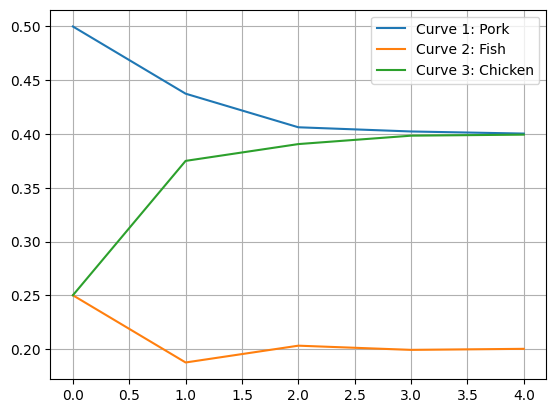

In [ ]:
plt.plot(small_storage)
plt.grid(True)
plt.legend(['Curve 1: Pork', 'Curve 2: Fish', 'Curve 3: Chicken'])
plt.show()

`plt.plot(small_storage)` is smart enough to notice `small_storage` has 3 columns and draws one line per column automatically — that's why you get three curves without asking for them individually. `plt.grid(True)` just adds gridlines.

## 8. Now: the actual cafe prediction model notebook, fully explained

You now know every single piece. Here is the whole code again, cell by cell, with nothing left unexplained.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

*(Same imports as Section 2.)*

In [ ]:
A = np.array([[0.5, 0.5, 0.25], [0.25, 0, 0.25], [0.25, 0.5, 0.5]])
print (A)

[[0.5  0.5  0.25]
 [0.25 0.   0.25]
 [0.25 0.5  0.5 ]]


*A 3×3 matrix (Section 3). Each column of `A` describes, given the weather today, how the probability splits across tomorrow's three possible states — this is what's called a Markov chain. Notice each column sums to 1, since tomorrow has to be* some *state.*

In [ ]:
xtoday = [1, 0, 0]

*The starting condition — "today" is state 1 with certainty (probability 1 in the first slot, 0 elsewhere). Note this is a plain Python list here, not a NumPy array yet — that's fine, `@` will still work with it.*

In [ ]:
# Matrix-vector multiplication
A @ xtoday

array([0.5 , 0.25, 0.25])

*One step into the future (Section 4) — tomorrow's probabilities, computed from today's.*

In [ ]:
the_food = np.zeros((50, 3))
the_food [0, :] = xtoday
for i in range(50):
    xtomorrow = A @ xtoday  # xtomorrow is linear combination of xtoday
    xtoday = xtomorrow
    the_food[i, :] = xtomorrow

*This is Sections 5–6 combined: make an empty 50×3 array to hold 50 days of results, then loop 50 times, each time multiplying by `A` to step one day forward and saving the result. After this cell runs, `the_food` holds the entire 50-day trajectory.*

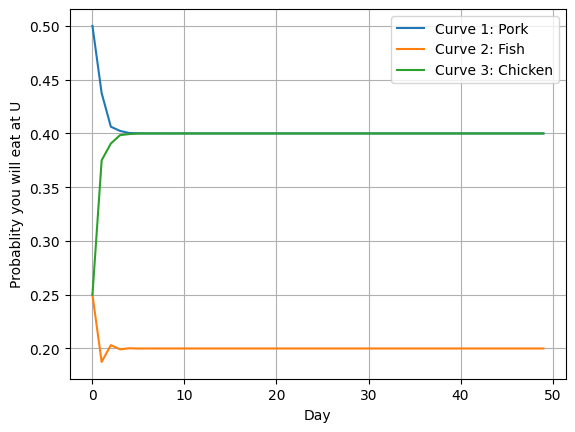

In [ ]:
plt.plot(the_food)
plt.grid(True)
plt.xlabel('Day')
plt.ylabel('Probablity you will eat at U')
plt.legend(['Curve 1: Pork', 'Curve 2: Fish', 'Curve 3: Chicken'])
plt.show()

*Section 7 — plot all three probability trajectories over the 50 days. Notice they settle down to steady values after a while, rather than oscillating forever — that settling behavior is exactly what the rest of the course is about explaining mathematically (via the eigenvalues of `A`).*

## You're ready

Make a prediction model on your own and run it top to bottom — every line should look familiar.

**A few things to try on your own, once it's running:**
- Change `xtoday` to a different starting state, like `[0, 1, 0]`. Does the long-run behavior change?
- Change `50` to a bigger or smaller number of days.
- Try editing a few entries of `A` (keeping each column summing to 1) and see how the steady-state values shift.

If you hit an error message, read the last line of it first — Python usually tells you plainly what went wrong (e.g., `NameError` means a variable wasn't defined yet, usually because an earlier cell wasn't run).